In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import pycirclize
from pycirclize import Circos
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.cm as cm
import os
import plotly.graph_objects as go
import networkx as nx
import plotly.io as pio
from collections import defaultdict
import matplotlib
from itertools import combinations
# ! pip install -U kaleido

In [5]:
# Use the directory of current notebook's working directory 
base_dir = os.path.dirname(os.getcwd())
data_dir = os.path.join(base_dir, "data") # Directory for input data files (Cluster_detail_results.csv, cluster_groups.csv)
output_dir = os.path.join(base_dir, "output")

# Create the output folder if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

In [10]:
# Load Clusters
df = pd.read_csv(os.path.join(data_dir, "Cluster_detail_results.csv"))
df_groups = pd.read_csv(os.path.join(data_dir, "cluster_groups_matlab.csv"))

df["Folder_Name"] = df["Folder_Name"].ffill()

# Preview current folder names
print("Current Folder_Name values:")
print(df["Folder_Name"].unique())

Current Folder_Name values:
['1_week8_1' '2_week8_2' '3_week10_1' '4_week10_2' '5_week12' '6_week14'
 '7_week23']


In [11]:

# Defines how each folder name maps to a stage ------------------- CHANGE HERE IF NEEDED -------------------
folder_to_stage = {
    "1_week8_1": "Stage 1",
    "2_week8_2": "Stage 1",
    "3_week10_1": "Stage 2",
    "4_week10_2": "Stage 2",
    "5_week12": "Stage 3",
    "6_week14": "Stage 4",
    "7_week23": "Stage 5"
}

# Replace the folder names using the mapping
df["Folder_Name"] = df["Folder_Name"].replace(folder_to_stage)

# Show result
print("\nUpdated folder names:")
print(df["Folder_Name"].unique())



Updated folder names:
['Stage 1' 'Stage 2' 'Stage 3' 'Stage 4' 'Stage 5']


In [18]:
# which plots are created so plots that don't need to be recreated can be skipped 
# Parameters
plots = {
    'cluster_usage_map': {
        'enabled': True,
        'stage_names': list(dict.fromkeys(folder_to_stage.values())),
        'save_dir': os.path.join(output_dir, 'Cluster_Usage_Maps')
    },
    'sankey_plot': {
        'enabled': False,
        'save_dir': os.path.join(output_dir, 'Sankey_Plots')
    },
    'grouped_sankey_plot': {
        'enabled': False,
        'save_dir': os.path.join(output_dir, 'Grouped_Sankey_Plots')
    },
    'transition_pie_chart': {
        'enabled': False,
        'save_dir': os.path.join(output_dir, 'Transition_Pie_Charts')
    },
    'grouped_transition_pie_chart': 
    {
        'enabled': False,
        'save_dir': os.path.join(output_dir, 'Grouped_Transition_Pie_Charts')
    },
    'transition_probability_matrix': {
        'enabled': False,
        'save_dir': os.path.join(output_dir, 'Transition_Probability_Matrices')
    },
}

In [ ]:

def plot_cluster_usage_map(df, stage_names, save_dir=None):
    filtered_dfs = []
    for stage in stage_names:
        filtered_df = df[df['Folder_Name'] == stage]
        filtered_dfs.append((stage, filtered_df))
    
    def create_cluster_usage_df(df):
        df = pd.DataFrame(df)
        df_cluster_usage = df['ClusterIdx'].value_counts().reset_index()
        df_cluster_usage.columns = ['ClusterIdx', 'count']
        df_cluster_usage['count'] = df_cluster_usage['count'].astype(int)
        total_count = df_cluster_usage['count'].sum()
        df_cluster_usage['percentage'] = df_cluster_usage['count'] / total_count * 100
        return df_cluster_usage

    # Cluster Usage DataFrames for each stage
    cluster_usage_dfs = []
    stage_cluster_usages = {}
    for stage, filtered_df in filtered_dfs:
        cluster_usage_df = create_cluster_usage_df(filtered_df)
        cluster_usage_df['Stage'] = stage
        cluster_usage_dfs.append(cluster_usage_df)
        stage_cluster_usages[stage] = cluster_usage_df.rename(columns={'percentage': f'percentage_{stage}'})

    # ---- pairwise changes between stages ----
    def create_pairwise_stage_changes(stage_cluster_usages, stage_names):
        """
        Compare cluster usage between all pairs of stages.

        Parameters:
            stage_cluster_usages: dict mapping stage name -> DataFrame with ['ClusterIdx', f'percentage_{stage}']
            stage_names: list of stage names (e.g., ['Stage 1', 'Stage 2', 'Stage 3'])

        Returns:
            List of DataFrames comparing each pair of stages, each with columns:
            ['ClusterIdx', f'percentage_{stage_x}', f'percentage_{stage_y}', 'change_in_usage']
        """
        results = []

        for stage_x, stage_y in combinations(stage_names, 2):
            df_x = stage_cluster_usages[stage_x]
            df_y = stage_cluster_usages[stage_y]

            merged_df = pd.merge(
                df_x[['ClusterIdx', f'percentage_{stage_x}']],
                df_y[['ClusterIdx', f'percentage_{stage_y}']],
                on='ClusterIdx',
                how='outer'
            )

            # Fill missing percentages with 0
            merged_df[f'percentage_{stage_x}'] = merged_df[f'percentage_{stage_x}'].fillna(0)
            merged_df[f'percentage_{stage_y}'] = merged_df[f'percentage_{stage_y}'].fillna(0)

            # Compute change in usage
            merged_df['change_in_usage'] = merged_df[f'percentage_{stage_y}'] - merged_df[f'percentage_{stage_x}']

            results.append(merged_df[['ClusterIdx', f'percentage_{stage_x}', f'percentage_{stage_y}', 'change_in_usage']])

        return results

    # Run the new comparison function
    stage_change_dfs = create_pairwise_stage_changes(stage_cluster_usages, stage_names)
    
    def create_heatmaps_from_stage_changes(pairwise_changes, stage_pairs, title="", save=False, paths=None):
        """
        Creates polar heatmaps for multiple pairwise stage changes.

        Parameters:
            pairwise_changes: list of DataFrames with 
                ['ClusterIdx', 'percentage_<StageX>', 'percentage_<StageY>', 'change_in_usage']
            stage_pairs: list of tuples [(StageX, StageY), ...] corresponding to the pairwise_changes
            title: string, base title for plots
            save: bool, whether to save figures
            paths: list of paths to save figures (same length as pairwise_changes)
        """

        # Flatten all change_in_usage values to get global min/max
        all_changes = np.concatenate([df['change_in_usage'].values for df in pairwise_changes])

        # Option 1: Automatic scaling from data
        # global_min = all_changes.min()
        # global_max = all_changes.max()
        # Option 2: Fixed scale (for consistency across plots)
        global_min = -4.77
        global_max = 4.53

        norm = TwoSlopeNorm(vmin=global_min, vcenter=0, vmax=global_max)

        for i, df in enumerate(pairwise_changes):
            clusters = df['ClusterIdx'].astype(int).values
            change_values = df['change_in_usage'].values
            colors = plt.cm.bwr(norm(change_values))

            fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
            theta = np.linspace(0, 2 * np.pi, len(clusters), endpoint=False)
            slice_width = 2 * np.pi / len(clusters)
            bar_width = slice_width * 0.9

            ax.bar(theta, np.ones(len(clusters)), color=colors, width=bar_width, bottom=0.5)

            # Labels
            label_offset = 0
            theta_labels = (theta + label_offset) % (2 * np.pi)
            ax.set_xticks(theta_labels)
            ax.set_xticklabels(clusters, fontsize=5.5, rotation=45)
            ax.set_yticklabels([])
            ax.set_yticks([])
            ax.tick_params(axis='x', pad=-8)
            ax.grid(False)
            ax.spines['polar'].set_visible(False)

            # Colorbar
            sm = plt.cm.ScalarMappable(cmap='bwr', norm=norm)
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.1)
            cbar.set_label("Change in Usage (%)")

            stage_x, stage_y = stage_pairs[i]
            plt.title(f"{title} Change in Cluster Usage ({stage_x} → {stage_y})")
            plt.tight_layout()

            # Optional saving
            if save and paths is not None:
                path = paths[i]
                eps_dir = os.path.dirname(path)
                if eps_dir:
                    os.makedirs(eps_dir, exist_ok=True)
                base_filename = os.path.splitext(os.path.basename(path))[0]
                eps_path = os.path.join(eps_dir, base_filename + '.eps')
                plt.savefig(eps_path, format='eps', bbox_inches='tight')
                print(f"EPS saved to: {eps_path}")

                parent_dir = os.path.dirname(eps_dir)
                png_dir = os.path.join(parent_dir, 'png')
                os.makedirs(png_dir, exist_ok=True)
                png_path = os.path.join(png_dir, base_filename + '.png')
                plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')
                print(f"PNG saved to: {png_path}")

            plt.show()
    stage_pairs = list(combinations(stage_names, 2))  # [('Stage 1','Stage 2'), ('Stage 1','Stage 3'), ...]
    create_heatmaps_from_stage_changes(stage_change_dfs, stage_pairs, title="Stage Comparison", save=True, paths)
    


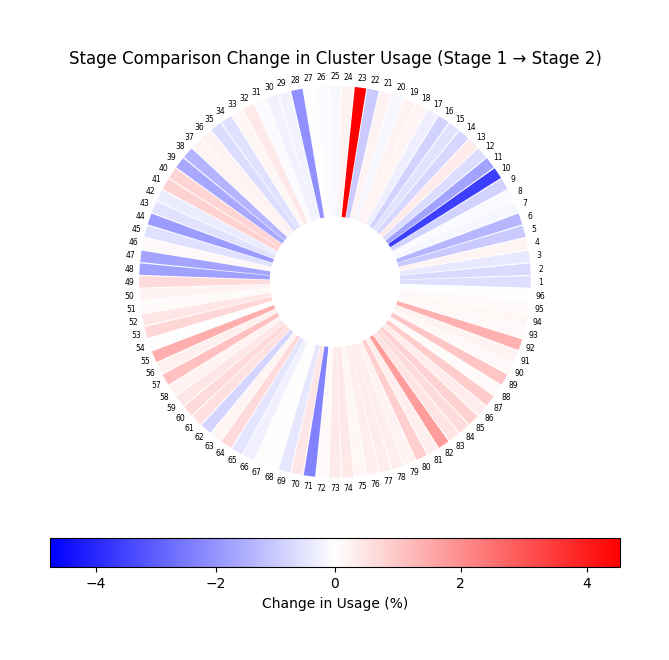

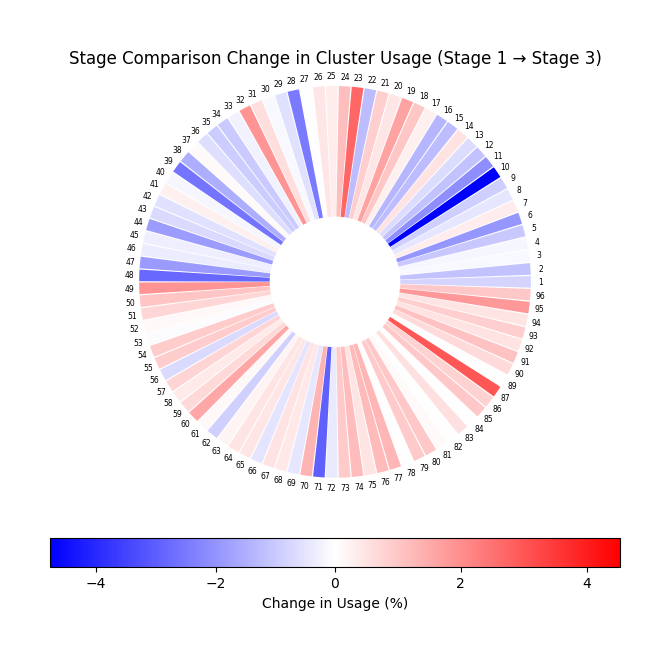

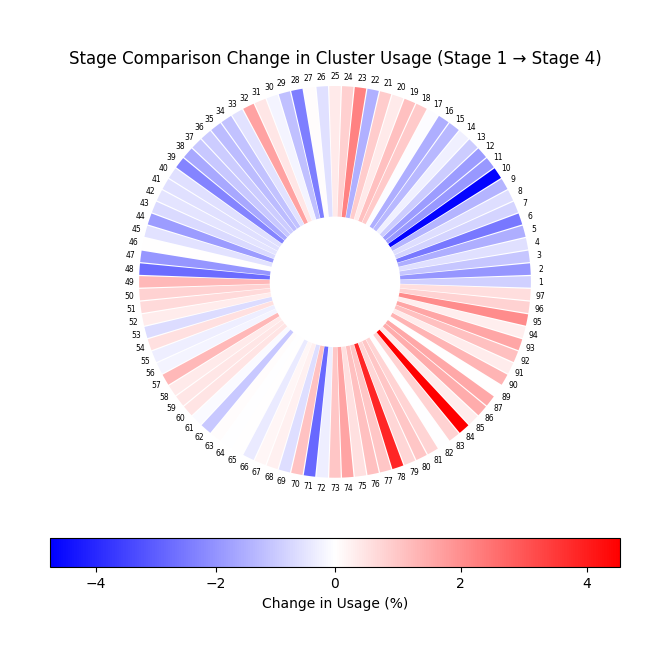

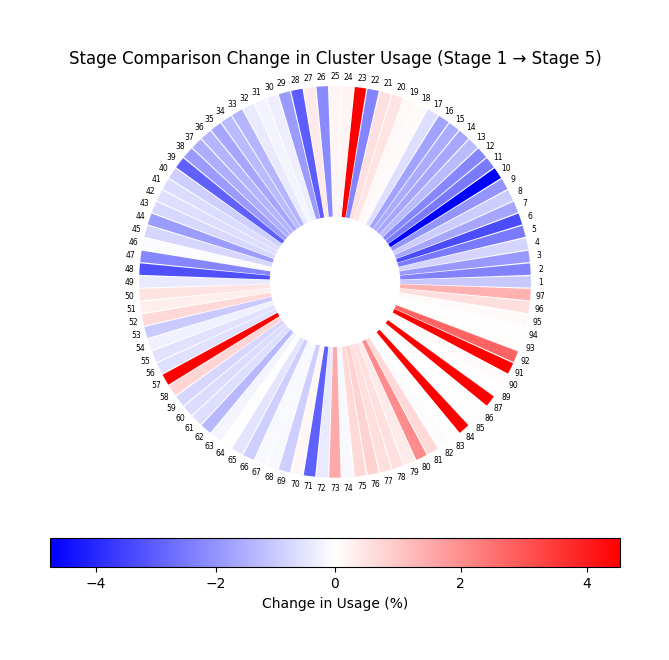

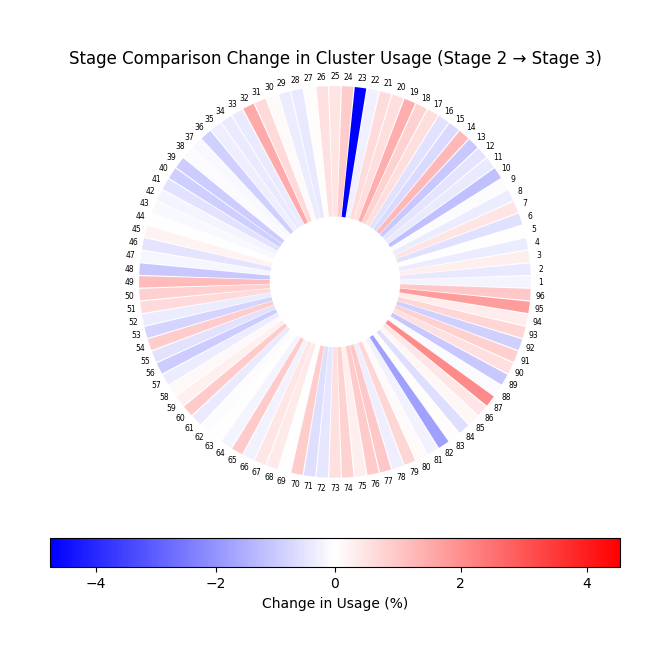

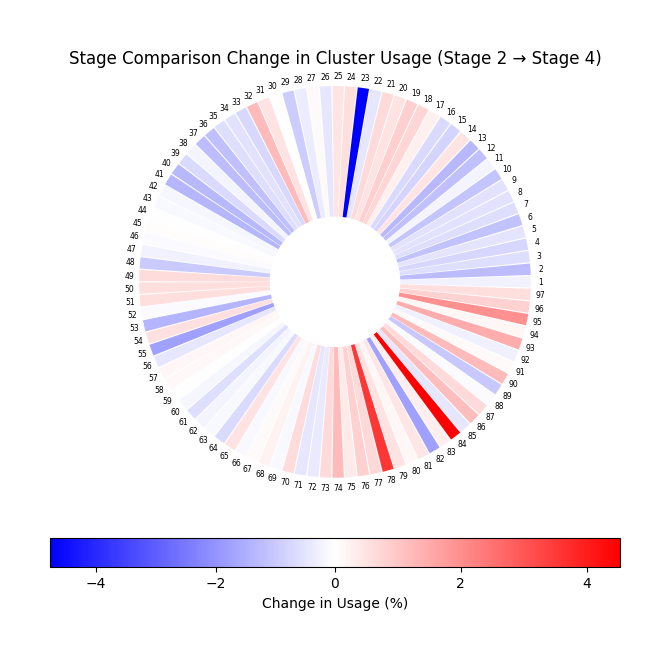

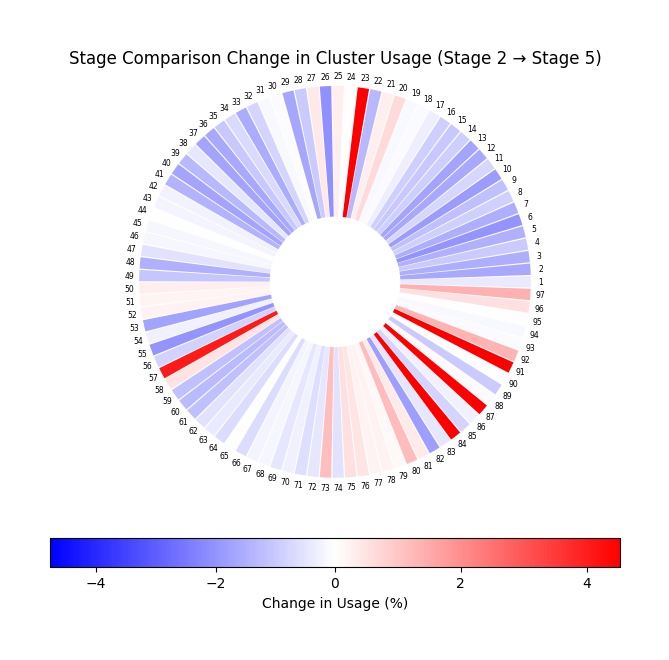

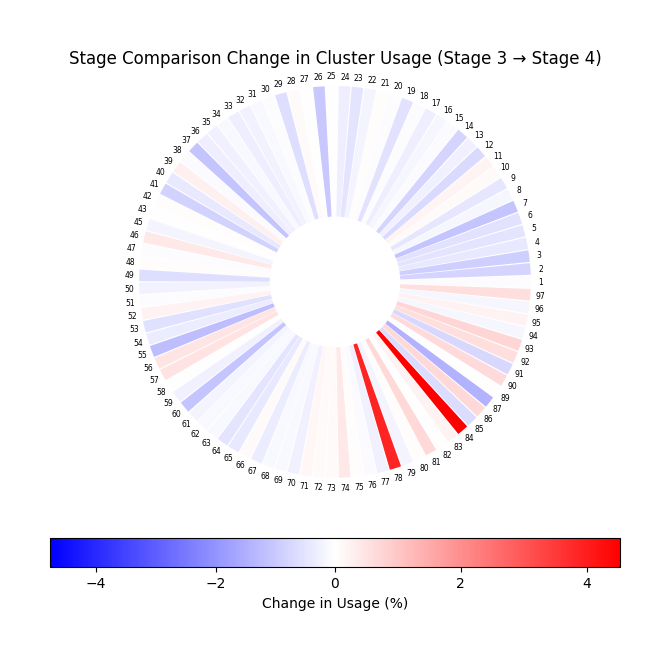

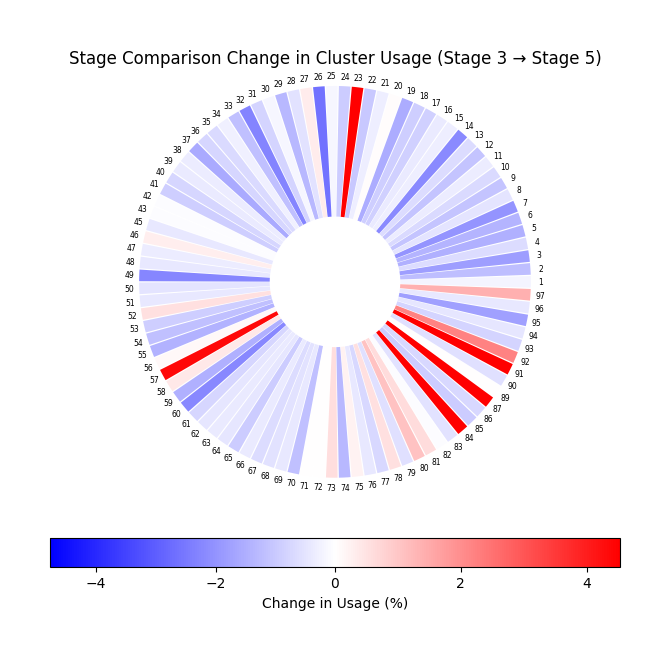

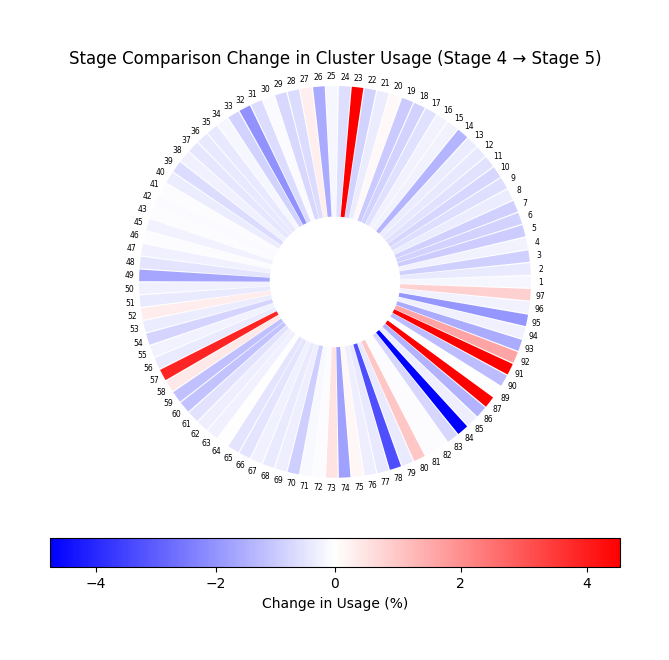

In [20]:

if plots['cluster_usage_map']['enabled'] == True:
    plot_cluster_usage_map(df, plots['cluster_usage_map']['stage_names'], plots['cluster_usage_map']['save_dir'])